# Data Cleaning

## Implementation of Data Cleaning in Python

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/Titanic-Dataset (1).csv')

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# drop passenger id column
df1 = df.drop('PassengerId', axis=1)
df1.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 111.9 KB


In [9]:
# select the numerical columns from the dataset
numerucal_cols = df1.select_dtypes(include=['int64', 'float64']).columns
numerucal_cols

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

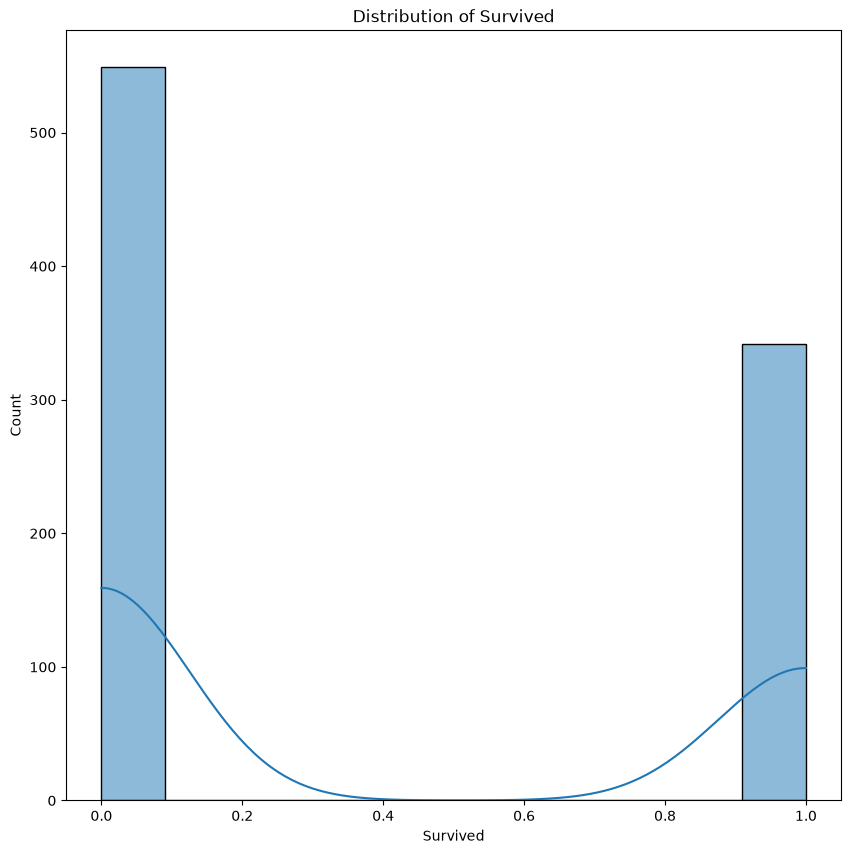

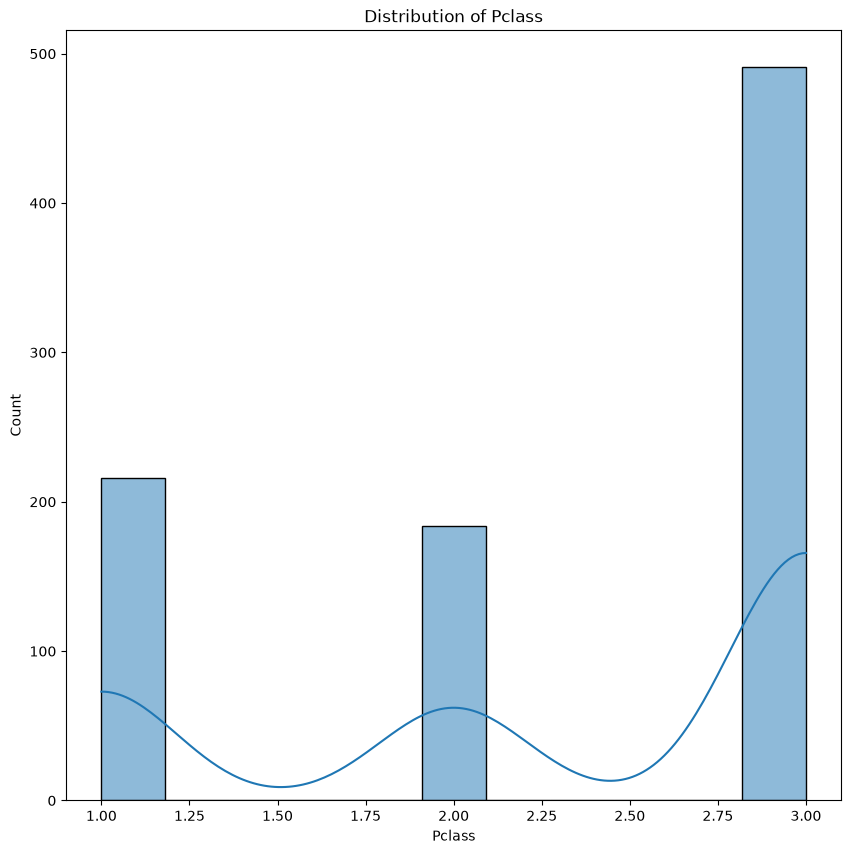

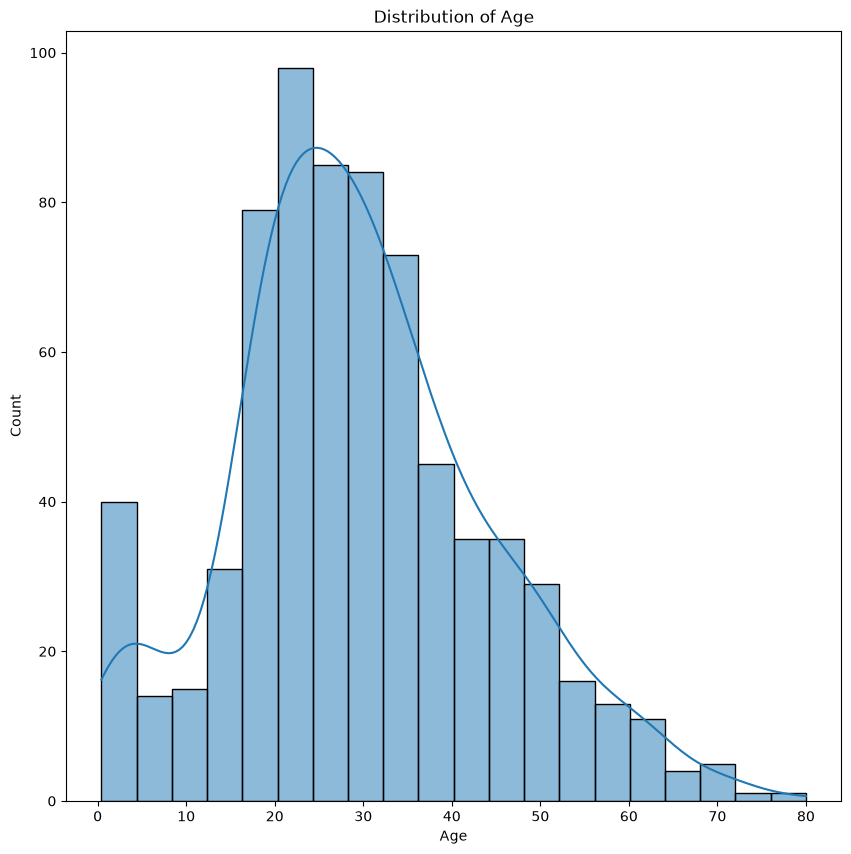

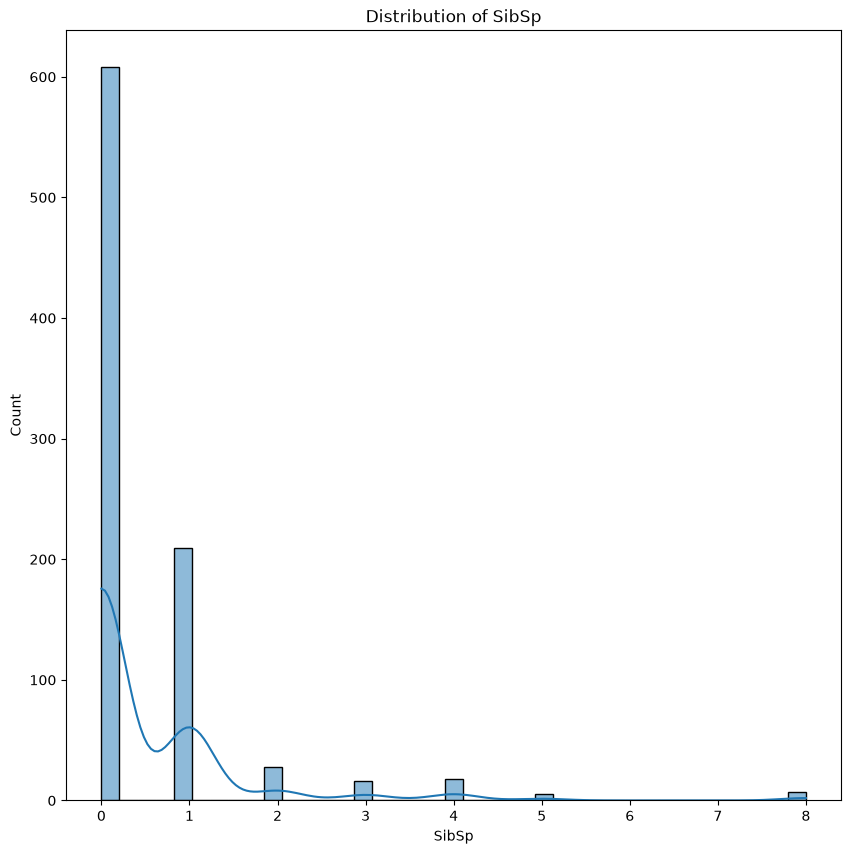

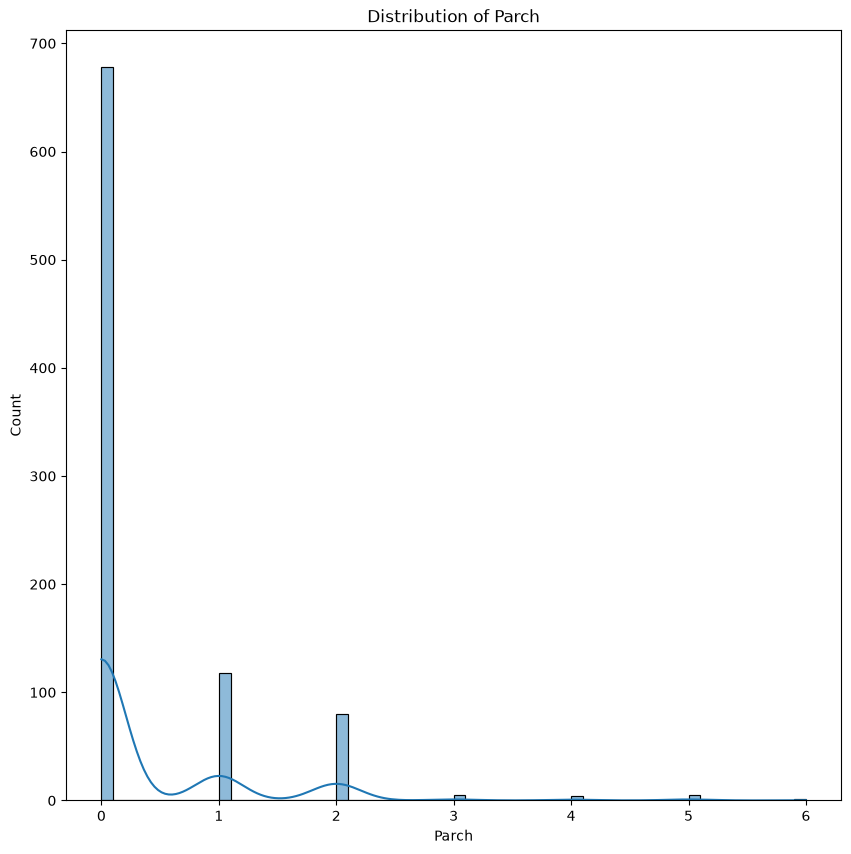

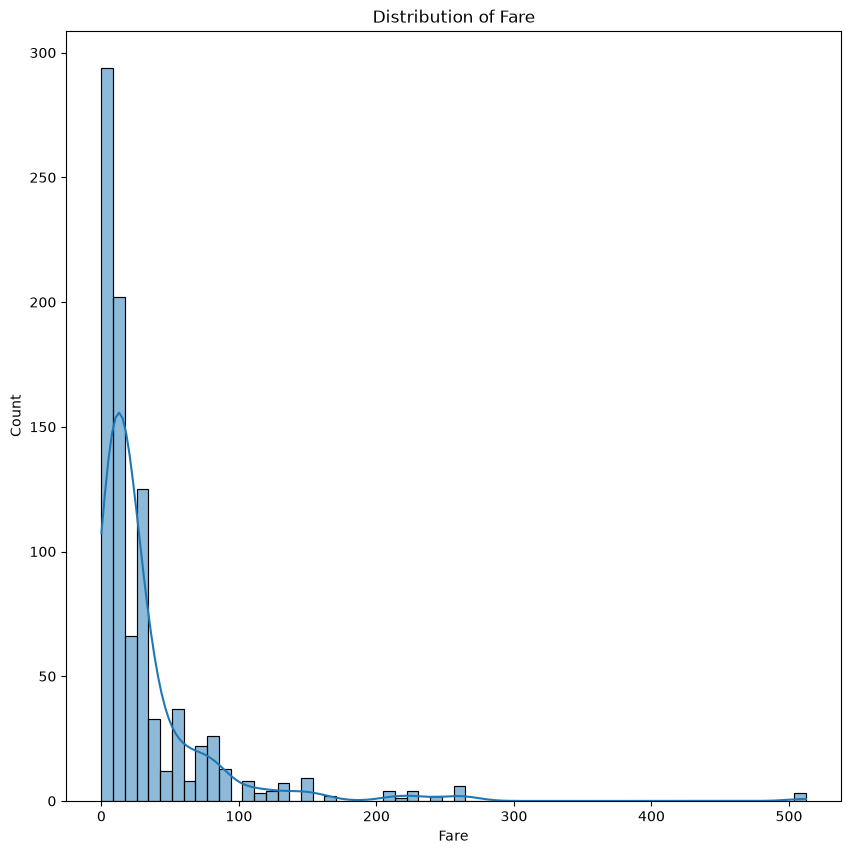

In [11]:
# check for distribution of numerical columns
for col in numerucal_cols:
    plt.figure(figsize=(10, 10))
    sns.histplot(df1[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

### Target Variable Analysis

In [12]:
df1['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

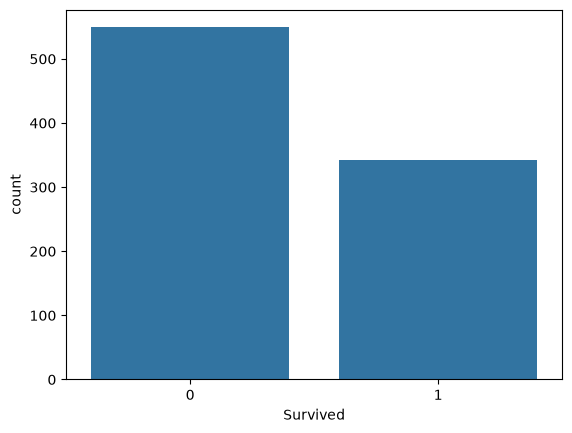

In [24]:
sns.barplot(df1['Survived'].value_counts())
plt.show()

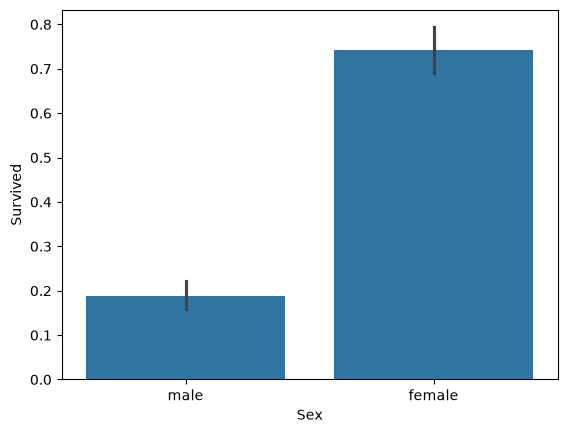

In [18]:
sns.barplot(x='Sex', y='Survived', data=df1)
plt.show()

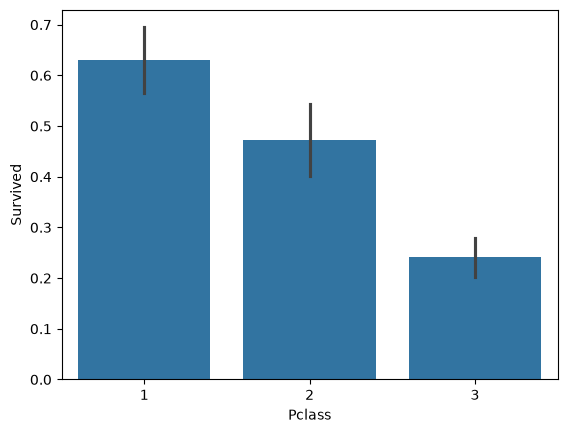

In [ ]:
# Pclass vs Survived
sns.barplot(x='Pclass', y='Survived', data=df1)
plt.show()

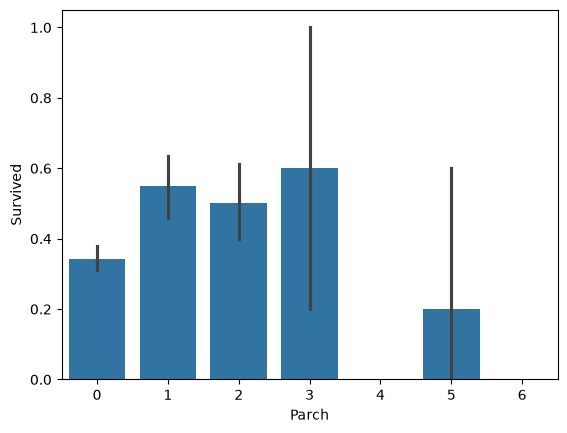

In [23]:
# Parch vs Survived
sns.barplot(x='Parch', y='Survived', data=df1)
plt.show()

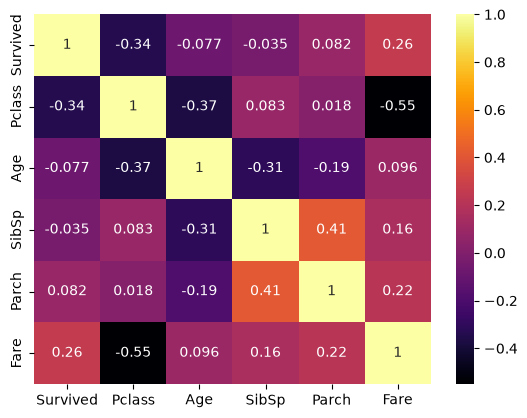

In [28]:
# correlation analysis
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='inferno')
plt.show()

In [29]:
# missing value analysis
df1.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [30]:
!pip3 install missingno


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [31]:
import missingno as msno

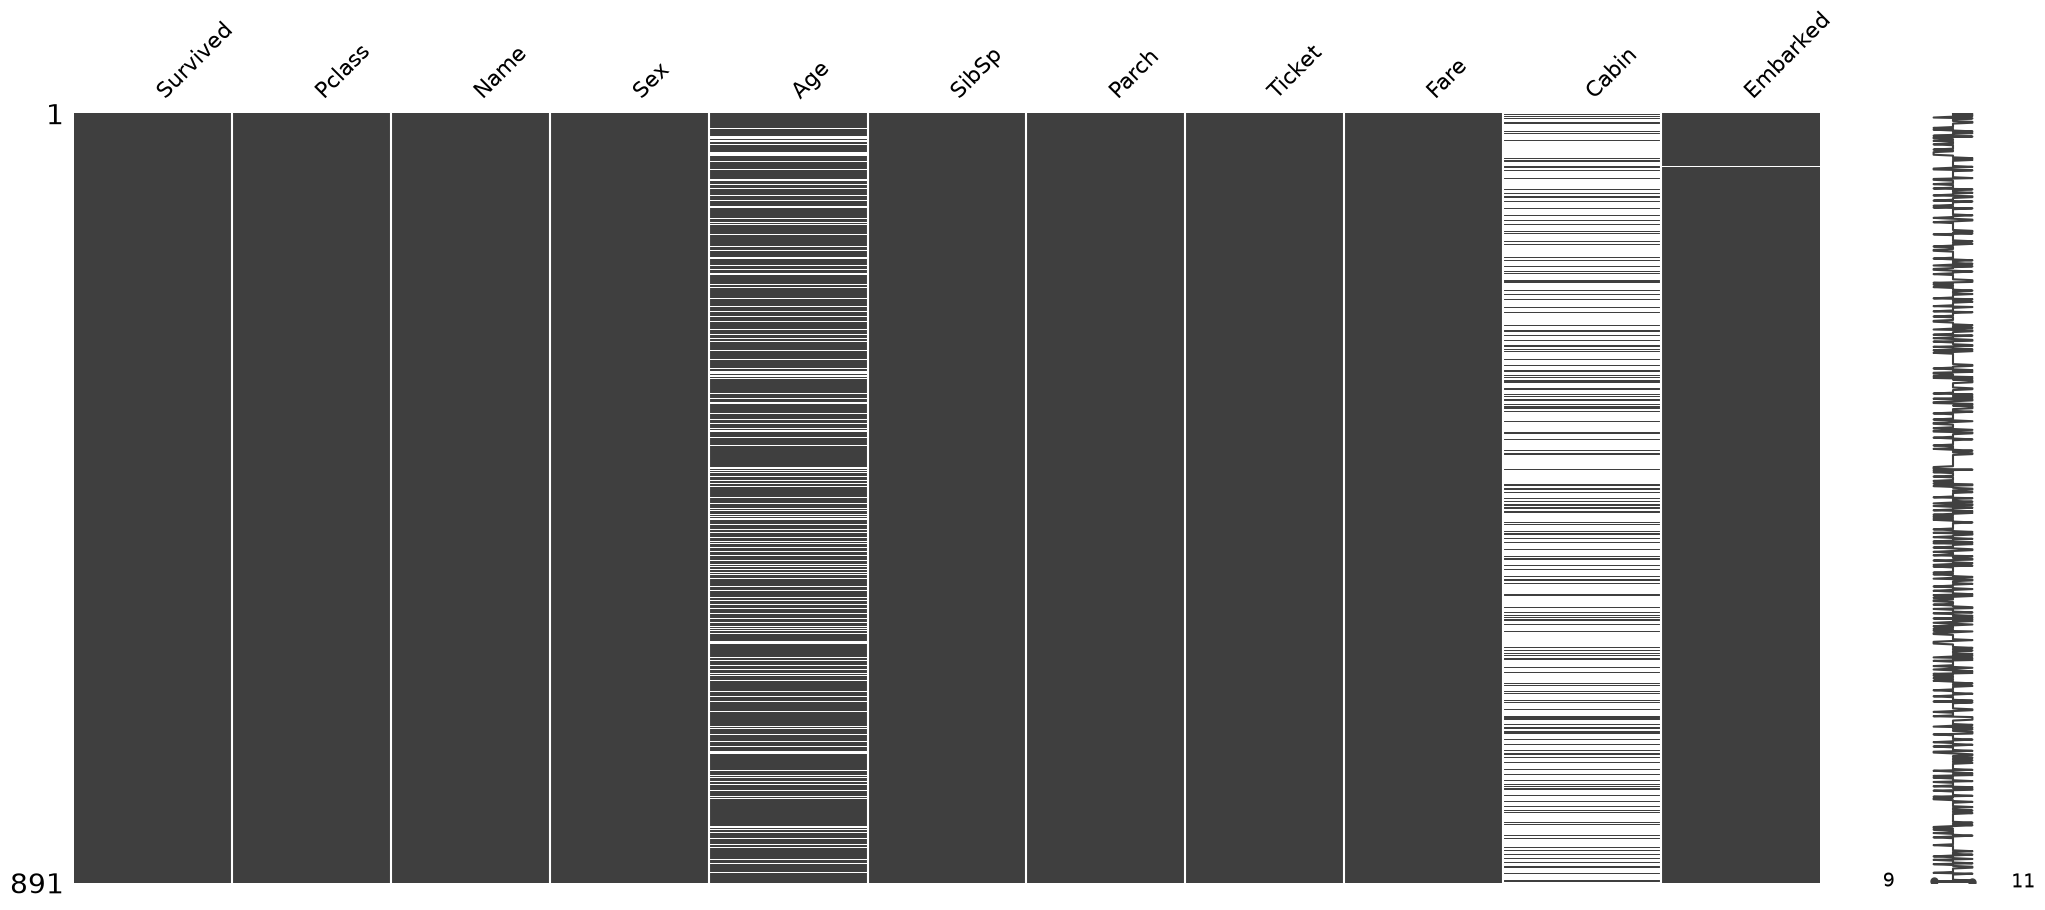

In [32]:
msno.matrix(df1)
plt.show()

In [34]:
# drop the irrelevant columns
df2 = df1.drop(['Name', 'Ticket', 'Cabin'], axis=1)

# age mean imputation
df2['Age'] = df2['Age'].fillna(df2['Age'].mean())

# embarked mode imputation
df2['Embarked'] = df2['Embarked'].fillna(df2['Embarked'].mode()[0])

/var/folders/2y/rw1f6sdn1_z84ny_s3mlv_1w0000gn/T/ipykernel_41013/1336925401.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df2['Age'], vert=False)


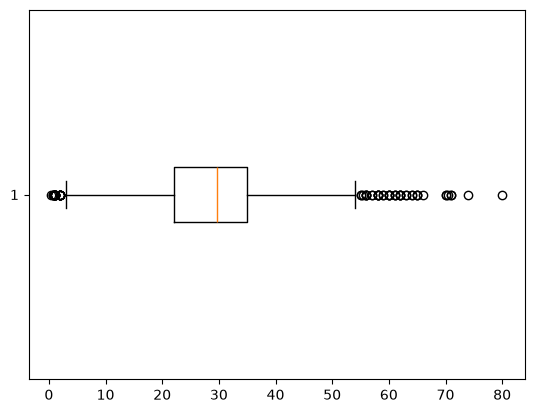

In [44]:
# check for outliers for age with boxplot
plt.boxplot(df2['Age'], vert=False)
plt.show()

## Calculate Outlier Boundaries and remove them

In [36]:
# compute the IQR for Q1 na Q3
Q1 = df2['Age'].quantile(0.25)
Q3 = df2['Age'].quantile(0.75)
IQR = Q3 - Q1

In [37]:
# define the bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [38]:
# filter the dataset to remove outliers
df3 = df2[(df2['Age'] >= lower_bound) & (df2['Age'] <= upper_bound)]


In [45]:
# check how many outliers were removed
print("Before:", len(df2))
print("After:", len(df3))

Before: 891
After: 825


/var/folders/2y/rw1f6sdn1_z84ny_s3mlv_1w0000gn/T/ipykernel_41013/3741631174.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df3['Age'], vert=False)


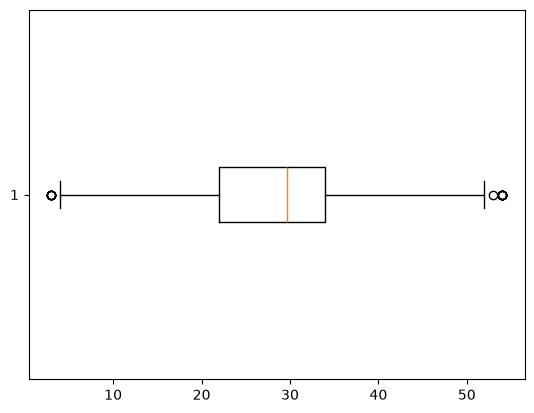

In [48]:
plt.boxplot(df3['Age'], vert=False)
plt.show()

# Enconding

In [49]:
cat_cols = [col for col in df3.columns if df3[col].dtype == 'str']
print(cat_cols)

['Sex', 'Embarked']


In [50]:
df3[cat_cols].nunique()

Sex         2
Embarked    3
dtype: int64

In [52]:
# using one hot encoding
df4 = pd.get_dummies(df3, columns=cat_cols, drop_first=True)
df4.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [53]:
bool_cols = ['Sex_male', 'Embarked_Q', 'Embarked_S']
df4[bool_cols] = df4[bool_cols].astype(int)

In [55]:
df4.head(10)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.000000,1,0,7.2500,1,0,1
1,1,1,38.000000,1,0,71.2833,0,0,0
2,1,3,26.000000,0,0,7.9250,0,0,1
3,1,1,35.000000,1,0,53.1000,0,0,1
4,0,3,35.000000,0,0,8.0500,1,0,1
5,0,3,29.699118,0,0,8.4583,1,1,0
6,0,1,54.000000,0,0,51.8625,1,0,1
8,1,3,27.000000,0,2,11.1333,0,0,1
9,1,2,14.000000,1,0,30.0708,0,0,0
10,1,3,4.000000,1,1,16.7000,0,0,1


# Feature Scaling

In [56]:
from sklearn.preprocessing import StandardScaler, RobustScaler

In [59]:
std_scaler = StandardScaler()
rob_scaler = RobustScaler()

In [61]:
df4[['Age', 'SibSp', 'Parch']] =  std_scaler.fit_transform(df4[['Age', 'SibSp', 'Parch']])
df4[['Fare']] = rob_scaler.fit_transform(df4[['Fare']])

In [62]:
df4.head(10)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,-0.676034,0.451484,-0.448025,-0.278092,1,0,1
1,1,1,0.896210,0.451484,-0.448025,2.609542,0,0,0
2,1,3,-0.282973,-0.465940,-0.448025,-0.247653,0,0,1
3,1,1,0.601414,0.451484,-0.448025,1.789551,0,0,1
4,0,3,0.601414,-0.465940,-0.448025,-0.242016,1,0,1
5,0,3,0.080521,-0.465940,-0.448025,-0.223603,1,1,0
6,0,1,2.468454,-0.465940,-0.448025,1.733745,1,0,1
8,1,3,-0.184708,-0.465940,2.057878,-0.102972,0,0,1
9,1,2,-1.462156,0.451484,-0.448025,0.751030,0,0,0
10,1,3,-2.444809,0.451484,0.804927,0.148063,0,0,1
